In [1]:
import sys
sys.path.append('../')
from reconstruction.resist import reconstruct
from utils.plotting_helper import make_cmap
import matplotlib.pyplot as plt
cmap = make_cmap()

In [2]:
# set path to model dir
model_dir = '../model/model_weights'

In [3]:
# set paths to electrodes and measurements 
# (electrodes should be of shape level x n_electrodes x 3)
# (signals should be of shape level x n_electrodes x (n_electrodes-3))
electrodes = 'test_data/electrodes.npy'
signals = 'test_data/signals.npy'

In [4]:
# use resist as backward model
tomogram_space, aspect_ratio = reconstruct(signals, 
                                           model_path=model_dir, 
                                           electrodes=electrodes, 
                                           n_electrodes=16, 
                                           verbose=False, 
                                           multiplier=1, 
                                           notebook=True, 
                                           return_aspect_ratio=True)

Could not load normalizing statistics, loading from file instead.


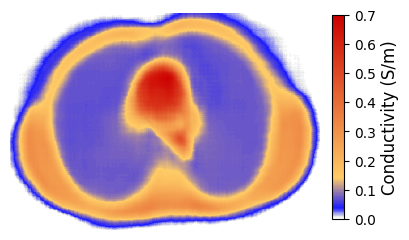

In [5]:
# visualize results
fig, axis = plt.subplots(1, 1, figsize=(4, 3))
axis.imshow(tomogram_space[0,0], cmap=cmap)
axis.set_aspect(aspect_ratio[0])
axis.axis('off')
cbar_ax = fig.add_axes([0.93, 0.17, 0.03, 0.68])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_clim(0, 0.7)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')        
cbar.set_label('Conductivity (S/m)')


In [6]:
# you can also change 
# - the resolution using `resolution`
# - the number of slices in the output space with `n_zpos`  
# - the view using `axis`
tomogram_space, aspect_ratio = reconstruct(signals, 
                                           model_path=model_dir, 
                                           electrodes=electrodes, 
                                           n_electrodes=16, 
                                           verbose=False, 
                                           multiplier=1, 
                                           notebook=True,
                                           n_zpos=128,
                                           resolution=128,
                                           axis='coronal', # axial, coronal, sagittal
                                           return_aspect_ratio=True)


Could not load normalizing statistics, loading from file instead.


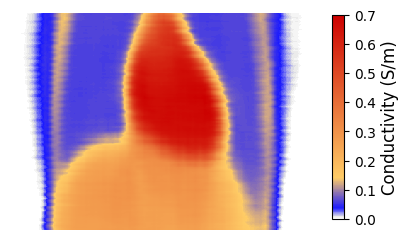

In [7]:
# visualize results
fig, axis = plt.subplots(1, 1, figsize=(4, 3))
axis.imshow(tomogram_space[0,32], cmap=cmap)
axis.set_aspect(aspect_ratio[0])
axis.axis('off')
cbar_ax = fig.add_axes([0.93, 0.17, 0.03, 0.68])  # [left, bottom, width, height]
sm = plt.cm.ScalarMappable(cmap=cmap)
sm.set_clim(0, 0.7)
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='vertical')        
cbar.set_label('Conductivity (S/m)')
